# 07. EDA de la base anual

Este notebook desarrolla el analisis descriptivo exploratorio de la base anual final de modelado.

## Objetivos
- revisar el comportamiento del target anual principal
- entender diferencias entre departamentos y años
- describir las variables productivas, economicas, climaticas y satelitales ya consolidadas
- identificar observaciones extremas, patrones generales y alertas metodologicas
- dejar insumos claros para el diseno experimental y el modelado baseline

## Enfoque
La lectura se centra en la base principal `departamento-anio`, coherente con la evidencia observada disponible en Agronet y con la definicion analitica adoptada en el proyecto.


## Comentario metodologico

Este notebook no busca demostrar causalidad ni seleccionar definitivamente el modelo. Su papel es entender la estructura empirica del dataset anual y verificar si la capa de modelado ya construida se comporta de forma razonable.

La exploracion se organiza en cinco bloques:

- perfil general de la base
- revision del target anual
- revision de variables productivas y economicas
- revision de variables climaticas y satelitales candidatas
- alertas de leakage, outliers y consideraciones para la siguiente fase


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

MATPLOTLIB_AVAILABLE = True
SEABORN_AVAILABLE = True

try:
    import matplotlib.pyplot as plt
except ImportError:
    MATPLOTLIB_AVAILABLE = False
    plt = None

try:
    import seaborn as sns
except ImportError:
    SEABORN_AVAILABLE = False
    sns = None

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 180)


def find_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / 'BASE_DE_DATOS').exists():
            return candidate
    raise FileNotFoundError('No se encontro una carpeta BASE_DE_DATOS en la ruta actual ni en sus padres.')


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)
BASE_DATOS = PROJECT_ROOT / 'BASE_DE_DATOS'
INPUT_PATH = BASE_DATOS / 'FINALES' / 'dataset_modelado_anual_limpio.csv'


In [ ]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f'No existe el archivo esperado: {INPUT_PATH}')

print('Rutas validadas correctamente.')
print('Matplotlib disponible:', MATPLOTLIB_AVAILABLE)
print('Seaborn disponible:', SEABORN_AVAILABLE)


Rutas validadas correctamente.
Matplotlib disponible: True
Seaborn disponible: True


## Carga de la base anual final

Esta base ya integra la informacion productiva anual observada, las variables economicas, los agregados climaticos y satelitales, asi como los metadatos finales de limpieza y trazabilidad.


In [ ]:
df = pd.read_csv(INPUT_PATH, sep=';')
df = df.sort_values(['departamento', 'anio']).reset_index(drop=True)

print('Shape base anual final:', df.shape)
display(df.head(5))


Shape base anual final: (36, 80)


,departamento,anio,rendimiento_t_ha,produccion_t,area_cosechada_ha,area_sembrada_ha,rendimiento_referencia_fullsample,rendimiento_referencia_prev,rendimiento_referencia_prev3,perdida_rendimiento_anual_pct,perdida_rendimiento_anual_pct_prev,perdida_rendimiento_anual_pct_prev3,evento_perdida_anual,perdida_real_pct,evento_perdida_real,diff_target_vs_perdida_real_pct,precio_ico_usd_ton,precio_productor_usd_ton,correccion_aplicada,motivo_correccion,n_municipios,produccion_t_original,rendimiento_t_ha_original,delta_produccion_t,delta_rendimiento_t_ha,rendimiento_medio_municipal_reportado,dif_rendimiento_calculado_vs_reportado,rendimiento_medio_t_ha,produccion_media_t,precipitation_annual_sum,temp_aire_C_annual_mean,humedad_relativa_pct_annual_mean,soil_annual_mean,def_annual_mean,pet_annual_mean,aet_annual_mean,GDD_cafe_annual_mean,NDVI_annual_mean,EVI_annual_mean,LST_Day_1km_annual_mean,LST_Night_1km_annual_mean,Gpp_annual_mean,Lai_500m_annual_mean,Fpar_500m_annual_mean,NDVI_anomalia_pct_annual_mean,EVI_anomalia_pct_annual_mean,Gpp_anomalia_pct_annual_mean,Lai_500m_anomalia_pct_annual_mean,precipitation_anomalia_pct_annual_mean,indice_perdida_annual_mean,precipitation_cosecha_sum,temp_aire_C_cosecha_mean,humedad_relativa_pct_cosecha_mean,soil_cosecha_mean,def_cosecha_mean,pet_cosecha_mean,aet_cosecha_mean,GDD_cafe_cosecha_mean,NDVI_cosecha_mean,EVI_cosecha_mean,LST_Day_1km_cosecha_mean,LST_Night_1km_cosecha_mean,Gpp_cosecha_mean,Lai_500m_cosecha_mean,Fpar_500m_cosecha_mean,NDVI_anomalia_pct_cosecha_mean,EVI_anomalia_pct_cosecha_mean,Gpp_anomalia_pct_cosecha_mean,Lai_500m_anomalia_pct_cosecha_mean,precipitation_anomalia_pct_cosecha_mean,indice_perdida_cosecha_mean,elevacion_media_m,elevacion_std_m,pendiente_media,pendiente_std,aspecto_medio,disponible_referencia_prev,disponible_referencia_prev3,listo_para_modelado_principal,version_target_principal
0,Cundinamarca,2007,0.784083,33729.143730,43017.30,48195.69,0.925118,NaN,NaN,-15.245048,NaN,NaN,1,-15.245048,1,8.881784e-15,2750.0,2145.0,0,sin_correccion,65.0,33729.143730,0.784083,0.000000,0.000000,0.629565,0.154518,0.925118,30017.744086,1687.793891,17.049639,78.108544,1041.084581,84.362900,914.525073,830.046049,7.766690,0.559274,0.358158,23.882376,11.317330,0.047687,1.857250,0.443968,-0.195160,-1.670301,-0.785513,2.800224,-6.275240,-0.883658,1098.347069,16.752371,82.927817,1187.465469,0.673783,836.745929,835.960358,7.622968,0.553130,0.358165,22.570806,11.000249,0.045257,1.793670,0.428554,-1.836137,-2.961987,-2.989640,0.026393,3.079408,-2.595921,1895.307361,1086.421734,14.454071,10.320921,185.295099,0,0,1,perdida_vs_referencia_fullsample
1,Cundinamarca,2008,0.818923,35732.355721,43633.35,48989.09,0.925118,0.784083,0.784083,-11.479062,4.443381,4.443381,0,-11.479062,0,1.243450e-14,2900.0,2262.0,1,Outlier de rendimiento de Cundinamarca 2008 corregido con promedio 2007-2009,66.0,78254.745626,1.793462,-42522.389905,-0.974539,1.908602,-0.115141,0.925118,30017.744086,1906.311791,16.676312,80.937549,1116.492910,24.495232,879.463229,854.818542,7.530276,0.549232,0.359143,23.041187,10.537202,0.046001,1.687877,0.420868,-2.102305,-1.553013,-4.110201,-7.360825,9.353536,-2.588506,1158.837926,16.641577,83.542475,1189.154816,0.285094,828.733359,828.321539,7.464702,0.547475,0.353955,22.929064,9.986722,0.044084,1.728891,0.426625,-3.050697,-4.335153,-5.295259,-5.319884,7.398212,-4.227036,1895.307361,1086.421734,14.454071,10.320921,185.295099,1,1,1,perdida_vs_referencia_fullsample
2,Cundinamarca,2009,0.853763,37118.057049,43475.84,48581.30,0.925118,0.801503,0.801503,-7.713077,6.520213,6.520213,0,-7.713077,0,1.065814e-14,2600.0,2028.0,0,sin_correccion,69.0,37118.057049,0.853763,0.000000,0.000000,0.751595,0.102168,0.925118,30017.744086,1588.434373,17.222820,78.467313,1124.390811,29.993428,939.235693,909.166882,8.070870,0.554271,0.361746,23.927916,12.172007,0.048055,1.796530,0.435888,-0.992592,-0.657007,0.398230,-0.680473,-4.401427,-0.417123,888.102849,17.276536,79.594043,1163.311099,16.596303,919.117149,902.4

## Perfil general de la base

Primero validamos su composicion basica para recordar que estamos trabajando con un panel pequeno, pero muy controlado, de dos departamentos y dieciocho años observados por departamento.


In [ ]:
general_summary = pd.DataFrame([
    {'indicador': 'filas', 'valor': int(df.shape[0])},
    {'indicador': 'columnas', 'valor': int(df.shape[1])},
    {'indicador': 'departamentos', 'valor': int(df['departamento'].nunique())},
    {'indicador': 'anio_min', 'valor': int(df['anio'].min())},
    {'indicador': 'anio_max', 'valor': int(df['anio'].max())},
    {'indicador': 'eventos_perdida_anual', 'valor': int(df['evento_perdida_anual'].sum())}
])

coverage = df.groupby('departamento').agg(
    anio_min=('anio', 'min'),
    anio_max=('anio', 'max'),
    observaciones=('anio', 'count'),
    eventos=('evento_perdida_anual', 'sum')
).reset_index()

nulls = df.isna().sum().sort_values(ascending=False).head(12).rename('nulos').reset_index().rename(columns={'index': 'variable'})

display(general_summary)
display(coverage)
display(nulls)


,indicador,valor
0,filas,36
1,columnas,80
2,departamentos,2
3,anio_min,2007
4,anio_max,2024
5,eventos_perdida_anual,7


,departamento,anio_min,anio_max,observaciones,eventos
0,Cundinamarca,2007,2024,18,3
1,Risaralda,2007,2024,18,4


,variable,nulos
0,rendimiento_referencia_prev,2
1,perdida_rendimiento_anual_pct_prev3,2
2,perdida_rendimiento_anual_pct_prev,2
3,rendimiento_referencia_prev3,2
4,produccion_t,0
5,departamento,0
6,rendimiento_t_ha,0
7,anio,0
8,rendimiento_referencia_fullsample,0
9,area_sembrada_ha,0


## Revision del target anual principal

La variable objetivo principal es `perdida_rendimiento_anual_pct`. Aqui nos interesa entender:

- su distribucion general
- las diferencias por departamento
- los años con eventos mas severos
- la relacion entre la version continua y la version binaria del evento


In [ ]:
target = 'perdida_rendimiento_anual_pct'

target_summary = pd.DataFrame([
    {'metrica': 'media', 'valor': float(df[target].mean())},
    {'metrica': 'mediana', 'valor': float(df[target].median())},
    {'metrica': 'desviacion_estandar', 'valor': float(df[target].std())},
    {'metrica': 'minimo', 'valor': float(df[target].min())},
    {'metrica': 'q1', 'valor': float(df[target].quantile(0.25))},
    {'metrica': 'q3', 'valor': float(df[target].quantile(0.75))},
    {'metrica': 'maximo', 'valor': float(df[target].max())}
])

target_by_dept = df.groupby('departamento')[target].agg(['count', 'mean', 'median', 'min', 'max', 'std']).reset_index()
event_balance = df['evento_perdida_anual'].value_counts(dropna=False).rename_axis('clase').reset_index(name='n')
event_by_dept = df.groupby('departamento')['evento_perdida_anual'].agg(['sum', 'count']).reset_index()
event_by_dept['proporcion_eventos'] = event_by_dept['sum'] / event_by_dept['count']

display(target_summary)
display(target_by_dept)
display(event_balance)
display(event_by_dept)


,metrica,valor
0,media,1.268121e-14
1,mediana,-2.794571e+00
2,desviacion_estandar,1.569158e+01
3,minimo,-3.152541e+01
4,q1,-1.050345e+01
5,q3,9.399641e+00
6,maximo,2.890424e+01


,departamento,count,mean,median,min,max,std
0,Cundinamarca,18,1.480297e-14,-4.897187,-25.345584,27.336301,15.973038
1,Risaralda,18,1.046077e-14,-0.794452,-31.525406,28.904244,15.868119


,clase,n
0,0,29
1,1,7


,departamento,sum,count,proporcion_eventos
0,Cundinamarca,3,18,0.166667
1,Risaralda,4,18,0.222222


In [ ]:
extremos = pd.concat([
    df.nsmallest(6, target),
    df.nlargest(6, target)
]).drop_duplicates().sort_values(target).reset_index(drop=True)

timeline = df[['departamento', 'anio', target, 'evento_perdida_anual', 'rendimiento_t_ha', 'rendimiento_referencia_fullsample']].copy()

print('Observaciones mas extremas del target:')
display(extremos[['departamento', 'anio', target, 'evento_perdida_anual', 'rendimiento_t_ha', 'rendimiento_referencia_fullsample']])

print('Serie anual del target por departamento:')
display(timeline)


Observaciones mas extremas del target:


,departamento,anio,perdida_rendimiento_anual_pct,evento_perdida_anual,rendimiento_t_ha,rendimiento_referencia_fullsample
0,Risaralda,2012,-31.525406,1,0.811384,1.184942
1,Cundinamarca,2013,-25.345584,1,0.690641,0.925118
2,Cundinamarca,2014,-19.247836,1,0.747053,0.925118
3,Risaralda,2013,-16.761596,1,0.986327,1.184942
4,Risaralda,2023,-16.033353,1,0.994956,1.184942
5,Risaralda,2022,-15.580839,1,1.000318,1.184942
6,Cundinamarca,2017,18.763149,0,1.098699,0.925118
7,Cundinamarca,2018,21.083382,0,1.120164,0.925118
8,Cundinamarca,2024,24.608568,0,1.152776,0.925118
9,Cundinamarca,2019,27.336301,0,1.178011,0.925118


Serie anual del target por departamento:


,departamento,anio,perdida_rendimiento_anual_pct,evento_perdida_anual,rendimiento_t_ha,rendimiento_referencia_fullsample
0,Cundinamarca,2007,-15.245048,1,0.784083,0.925118
1,Cundinamarca,2008,-11.479062,0,0.818923,0.925118
2,Cundinamarca,2009,-7.713077,0,0.853763,0.925118
3,Cundinamarca,2010,-9.120406,0,0.840743,0.925118
4,Cundinamarca,2011,-5.456866,0,0.874635,0.925118
5,Cundinamarca,2012,-10.482027,0,0.828147,0.925118
6,Cundinamarca,2013,-25.345584,1,0.690641,0.925118
7,Cundinamarca,2014,-19.247836,1,0.747053,0.925118
8,Cundinamarca,2015,-1.213192,0,0.913894,0.925118
9,Cundinamarca,2016,2.233614,0,0.945781,0.925118


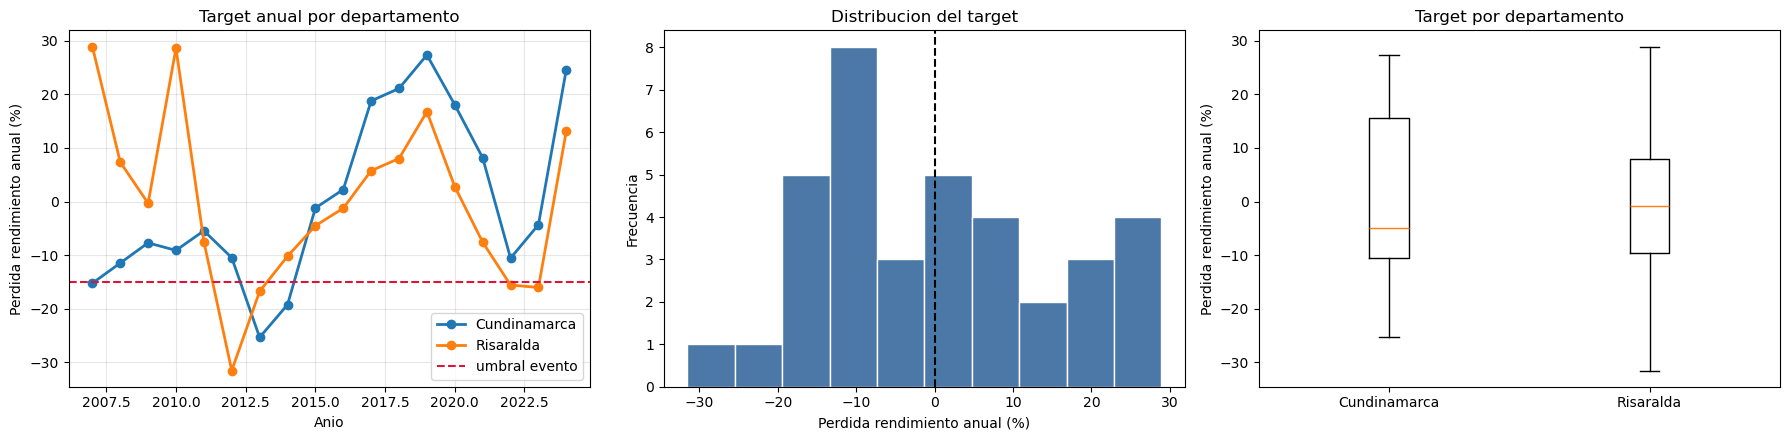

In [ ]:
if MATPLOTLIB_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    for dept, subdf in df.groupby('departamento'):
        axes[0].plot(subdf['anio'], subdf[target], marker='o', linewidth=2, label=dept)
    axes[0].axhline(-15, color='crimson', linestyle='--', linewidth=1.5, label='umbral evento')
    axes[0].set_title('Target anual por departamento')
    axes[0].set_xlabel('Anio')
    axes[0].set_ylabel('Perdida rendimiento anual (%)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].hist(df[target], bins=10, color='#4C78A8', edgecolor='white')
    axes[1].axvline(df[target].mean(), color='black', linestyle='--', linewidth=1.5)
    axes[1].set_title('Distribucion del target')
    axes[1].set_xlabel('Perdida rendimiento anual (%)')
    axes[1].set_ylabel('Frecuencia')

    dept_values = [df.loc[df['departamento'] == dept, target].values for dept in sorted(df['departamento'].unique())]
    axes[2].boxplot(dept_values, tick_labels=sorted(df['departamento'].unique()))
    axes[2].set_title('Target por departamento')
    axes[2].set_ylabel('Perdida rendimiento anual (%)')

    plt.tight_layout()
    plt.show()
else:
    print('No hay matplotlib disponible en este runtime. Las tablas anteriores cumplen la funcion descriptiva principal.')


## Variables productivas y economicas

En este bloque revisamos si las variables de produccion, rendimiento, area y precio muestran patrones coherentes y utiles para la etapa de modelado.


In [ ]:
productive_cols = [
    'rendimiento_t_ha', 'produccion_t', 'area_cosechada_ha', 'area_sembrada_ha',
    'precio_ico_usd_ton', 'precio_productor_usd_ton'
]

productive_summary = df.groupby('departamento')[productive_cols].agg(['mean', 'median', 'min', 'max'])
productive_summary.columns = ['_'.join(col) for col in productive_summary.columns]
productive_summary = productive_summary.reset_index()

productive_corr = df[productive_cols + [target]].corr(numeric_only=True)[[target]].sort_values(target)

display(productive_summary)
display(productive_corr)


,departamento,rendimiento_t_ha_mean,rendimiento_t_ha_median,rendimiento_t_ha_min,rendimiento_t_ha_max,produccion_t_mean,produccion_t_median,produccion_t_min,produccion_t_max,area_cosechada_ha_mean,area_cosechada_ha_median,area_cosechada_ha_min,area_cosechada_ha_max,area_sembrada_ha_mean,area_sembrada_ha_median,area_sembrada_ha_min,area_sembrada_ha_max,precio_ico_usd_ton_mean,precio_ico_usd_ton_median,precio_ico_usd_ton_min,precio_ico_usd_ton_max,precio_productor_usd_ton_mean,precio_productor_usd_ton_median,precio_productor_usd_ton_min,precio_productor_usd_ton_max
0,Cundinamarca,0.925118,0.879813,0.690641,1.178011,30017.744086,30975.78458,20898.20,37214.8,33140.231257,33418.851315,23797.69,44264.16,38059.183889,37798.105,27873.16,49357.78,3594.444444,3050.0,2600.0,6000.0,2803.666667,2379.0,2028.0,4680.0
1,Risaralda,1.184942,1.175528,0.811384,1.527441,46805.540217,44968.32540,32344.99,72842.5,39377.249372,39885.030000,30750.61,47689.25,48822.592222,50527.730,40856.38,55714.64,3594.444444,3050.0,2600.0,6000.0,2803.666667,2379.0,2028.0,4680.0


,perdida_rendimiento_anual_pct
area_sembrada_ha,-0.274059
area_cosechada_ha,-0.256593
precio_ico_usd_ton,-0.112215
precio_productor_usd_ton,-0.112215
produccion_t,0.371746
rendimiento_t_ha,0.778592
perdida_rendimiento_anual_pct,1.000000


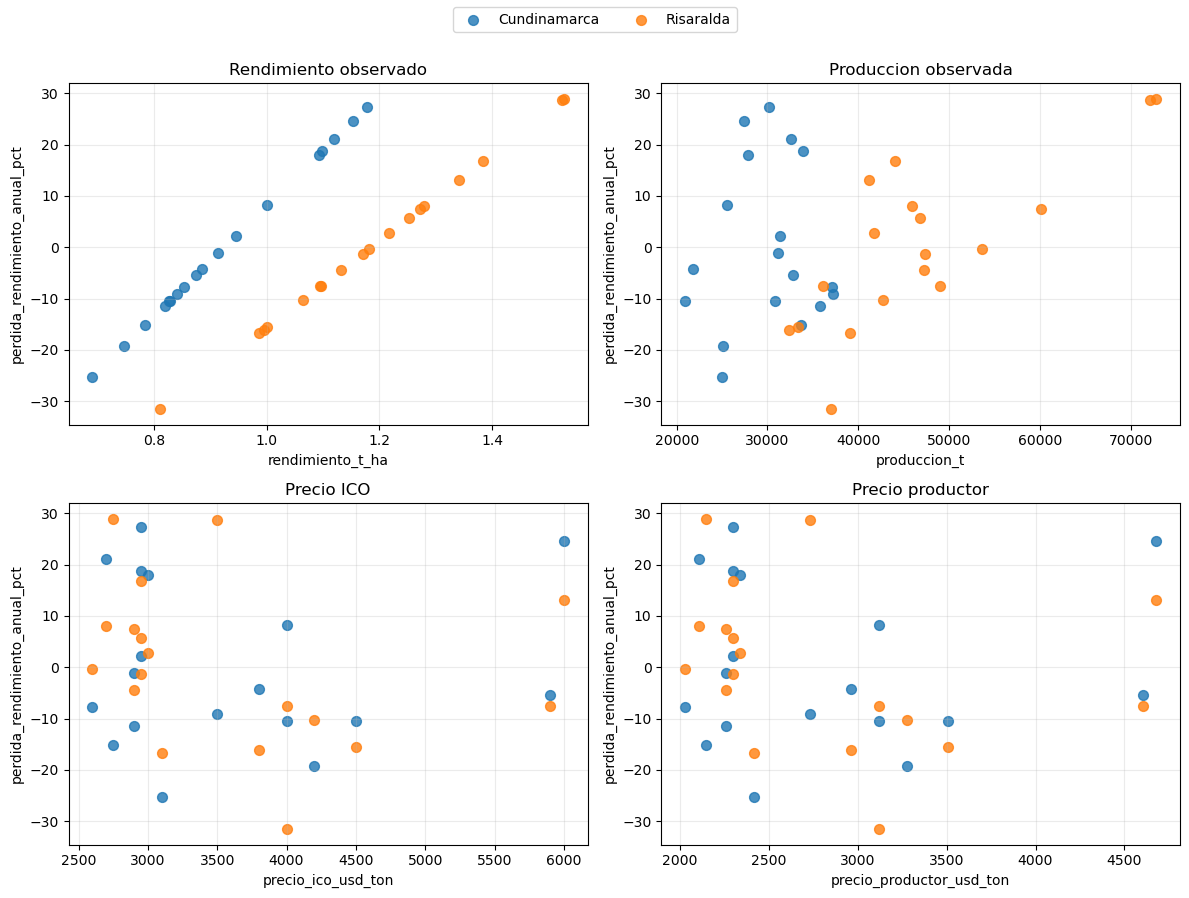

In [ ]:
if MATPLOTLIB_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    scatter_specs = [
        ('rendimiento_t_ha', 'Rendimiento observado'),
        ('produccion_t', 'Produccion observada'),
        ('precio_ico_usd_ton', 'Precio ICO'),
        ('precio_productor_usd_ton', 'Precio productor')
    ]
    colors = {'Cundinamarca': '#1f77b4', 'Risaralda': '#ff7f0e'}

    for ax, (col, title) in zip(axes, scatter_specs):
        for dept, subdf in df.groupby('departamento'):
            ax.scatter(subdf[col], subdf[target], s=50, alpha=0.8, label=dept, color=colors.get(dept))
        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel(target)
        ax.grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print('No hay matplotlib disponible para los graficos de dispersion productivos.')


## Variables climaticas y satelitales candidatas

Aqui no estamos haciendo seleccion final de variables, pero si una primera lectura orientada al modelado para saber que señales parecen mas prometedoras en la capa anual y en la capa de cosecha.


In [ ]:
annual_feature_candidates = [
    'precipitation_annual_sum', 'temp_aire_C_annual_mean', 'humedad_relativa_pct_annual_mean',
    'soil_annual_mean', 'def_annual_mean', 'pet_annual_mean', 'aet_annual_mean',
    'GDD_cafe_annual_mean', 'NDVI_annual_mean', 'EVI_annual_mean', 'LST_Day_1km_annual_mean',
    'LST_Night_1km_annual_mean', 'Gpp_annual_mean', 'Lai_500m_annual_mean', 'Fpar_500m_annual_mean',
    'NDVI_anomalia_pct_annual_mean', 'EVI_anomalia_pct_annual_mean', 'Gpp_anomalia_pct_annual_mean',
    'Lai_500m_anomalia_pct_annual_mean', 'precipitation_anomalia_pct_annual_mean', 'indice_perdida_annual_mean'
]

cosecha_feature_candidates = [
    'precipitation_cosecha_sum', 'temp_aire_C_cosecha_mean', 'humedad_relativa_pct_cosecha_mean',
    'soil_cosecha_mean', 'def_cosecha_mean', 'pet_cosecha_mean', 'aet_cosecha_mean',
    'GDD_cafe_cosecha_mean', 'NDVI_cosecha_mean', 'EVI_cosecha_mean', 'LST_Day_1km_cosecha_mean',
    'LST_Night_1km_cosecha_mean', 'Gpp_cosecha_mean', 'Lai_500m_cosecha_mean', 'Fpar_500m_cosecha_mean',
    'NDVI_anomalia_pct_cosecha_mean', 'EVI_anomalia_pct_cosecha_mean', 'Gpp_anomalia_pct_cosecha_mean',
    'Lai_500m_anomalia_pct_cosecha_mean', 'precipitation_anomalia_pct_cosecha_mean', 'indice_perdida_cosecha_mean'
]

corr_annual = (
    df[annual_feature_candidates + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename('corr_con_target')
    .reset_index()
    .rename(columns={'index': 'variable'})
)

corr_cosecha = (
    df[cosecha_feature_candidates + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename('corr_con_target')
    .reset_index()
    .rename(columns={'index': 'variable'})
)

print('Top 10 correlaciones absolutas de la capa anual:')
display(corr_annual.head(10))
print('Top 10 correlaciones absolutas de la capa de cosecha:')
display(corr_cosecha.head(10))


Top 10 correlaciones absolutas de la capa anual:


,variable,corr_con_target
0,temp_aire_C_annual_mean,0.331495
1,def_annual_mean,0.308136
2,Lai_500m_anomalia_pct_annual_mean,0.179666
3,aet_annual_mean,-0.164395
4,EVI_anomalia_pct_annual_mean,0.150598
5,precipitation_anomalia_pct_annual_mean,-0.144590
6,indice_perdida_annual_mean,0.133760
7,EVI_annual_mean,0.131288
8,Gpp_anomalia_pct_annual_mean,0.117941
9,Gpp_annual_mean,0.113387


Top 10 correlaciones absolutas de la capa de cosecha:


,variable,corr_con_target
0,temp_aire_C_cosecha_mean,0.237427
1,NDVI_anomalia_pct_cosecha_mean,-0.200190
2,NDVI_cosecha_mean,-0.193444
3,indice_perdida_cosecha_mean,-0.141410
4,def_cosecha_mean,0.096740
5,EVI_anomalia_pct_cosecha_mean,-0.090535
6,EVI_cosecha_mean,-0.085927
7,Fpar_500m_cosecha_mean,-0.080246
8,aet_cosecha_mean,-0.078534
9,Lai_500m_anomalia_pct_cosecha_mean,-0.075696


,temp_aire_C_annual_mean,def_annual_mean,Lai_500m_anomalia_pct_annual_mean,aet_annual_mean,EVI_anomalia_pct_annual_mean,temp_aire_C_cosecha_mean,NDVI_anomalia_pct_cosecha_mean,NDVI_cosecha_mean,indice_perdida_cosecha_mean,def_cosecha_mean,perdida_rendimiento_anual_pct
temp_aire_C_annual_mean,1.000,0.170,0.601,0.387,0.473,0.939,0.417,0.376,0.441,0.152,0.331
def_annual_mean,0.170,1.000,0.241,-0.492,0.169,-0.031,0.162,0.213,0.179,0.357,0.308
Lai_500m_anomalia_pct_annual_mean,0.601,0.241,1.000,0.230,0.887,0.572,0.781,0.778,0.784,0.209,0.180
aet_annual_mean,0.387,-0.492,0.230,1.000,0.323,0.511,0.196,0.152,0.233,-0.208,-0.164
EVI_anomalia_pct_annual_mean,0.473,0.169,0.887,0.323,1.000,0.466,0.721,0.721,0.740,0.022,0.151
temp_aire_C_cosecha_mean,0.939,-0.031,0.572,0.511,0.466,1.000,0.457,0.411,0.501,0.190,0.237
NDVI_anomalia_pct_cosecha_mean,0.417,0.162,0.781,0.196,0.721,0.457,1.000,0.996,0.965,0.156,-0.200
NDVI_cosecha_mean,0.376,0.213,0.778,0.152,0.721,0.411,0.996,1.000,0.959,0.188,-0.193
indice_perdida_cosecha_mean,0.441,0.179,0.784,0.233,0.740,0.501,0.965,0.959,1.000,0.212,-0.141
def_cosecha_mean,0.152,0.357,0.209,-0.208,0.022,0.190,0.156,0.188,0.212,1.000,0.097


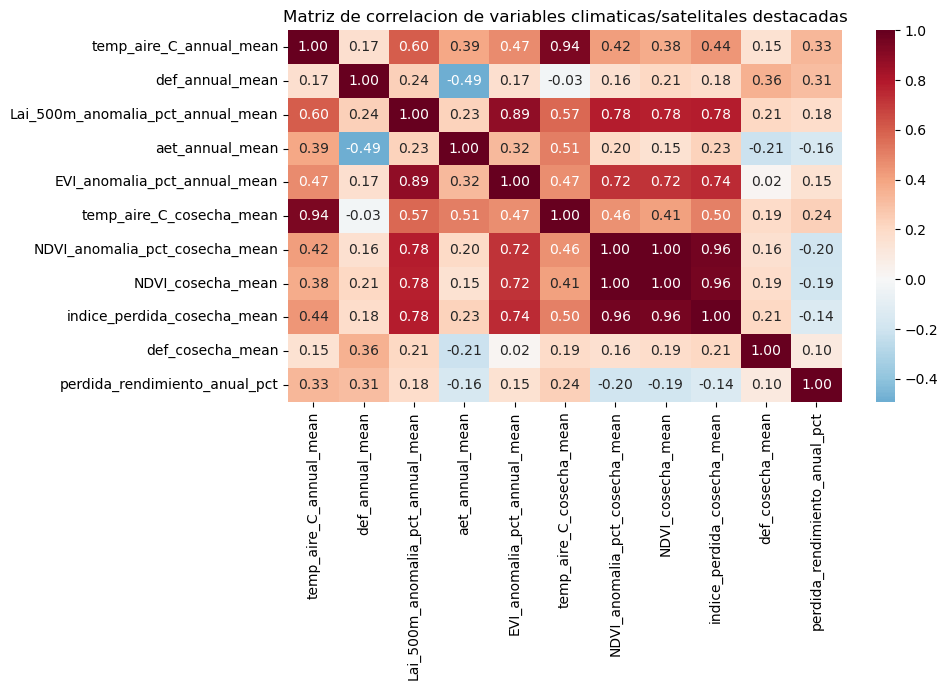

In [ ]:
top_climate_vars = corr_annual.head(5)['variable'].tolist() + corr_cosecha.head(5)['variable'].tolist()
top_climate_vars = list(dict.fromkeys(top_climate_vars))

corr_matrix_top = df[top_climate_vars + [target]].corr(numeric_only=True).round(3)
display(corr_matrix_top)

if MATPLOTLIB_AVAILABLE and SEABORN_AVAILABLE:
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix_top, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
    plt.title('Matriz de correlacion de variables climaticas/satelitales destacadas')
    plt.tight_layout()
    plt.show()
elif MATPLOTLIB_AVAILABLE:
    plt.figure(figsize=(10, 7))
    plt.imshow(corr_matrix_top, cmap='coolwarm', vmin=-1, vmax=1)
    plt.xticks(range(len(corr_matrix_top.columns)), corr_matrix_top.columns, rotation=90)
    plt.yticks(range(len(corr_matrix_top.index)), corr_matrix_top.index)
    plt.colorbar()
    plt.title('Matriz de correlacion de variables climaticas/satelitales destacadas')
    plt.tight_layout()
    plt.show()
else:
    print('No hay librerias graficas disponibles para la matriz de correlacion. La tabla anterior resume la relacion entre variables.')


## Alertas metodologicas para el modelado

No toda variable con alta correlacion debe entrar al modelo. Algunas columnas funcionan mejor como metadatos, chequeos o variables auxiliares y no como predictores principales.


In [ ]:
leakage_or_auxiliary = [
    'perdida_real_pct', 'evento_perdida_real', 'diff_target_vs_perdida_real_pct',
    'perdida_rendimiento_anual_pct_prev', 'perdida_rendimiento_anual_pct_prev3',
    'correccion_aplicada', 'motivo_correccion', 'listo_para_modelado_principal',
    'version_target_principal'
]

recommended_feature_pool = [
    'precipitation_annual_sum', 'temp_aire_C_annual_mean', 'humedad_relativa_pct_annual_mean',
    'soil_annual_mean', 'def_annual_mean', 'pet_annual_mean', 'aet_annual_mean',
    'GDD_cafe_annual_mean', 'NDVI_annual_mean', 'EVI_annual_mean', 'Gpp_annual_mean',
    'Lai_500m_annual_mean', 'Fpar_500m_annual_mean', 'precipitation_anomalia_pct_annual_mean',
    'NDVI_anomalia_pct_annual_mean', 'EVI_anomalia_pct_annual_mean', 'Gpp_anomalia_pct_annual_mean',
    'precipitation_cosecha_sum', 'temp_aire_C_cosecha_mean', 'humedad_relativa_pct_cosecha_mean',
    'NDVI_cosecha_mean', 'EVI_cosecha_mean', 'Gpp_cosecha_mean', 'indice_perdida_cosecha_mean',
    'precio_ico_usd_ton', 'precio_productor_usd_ton', 'elevacion_media_m', 'pendiente_media'
]

feature_notes = pd.DataFrame([
    {'grupo': 'no_usar_como_feature_principal', 'variables': ', '.join(leakage_or_auxiliary)},
    {'grupo': 'pool_inicial_sugerido', 'variables': ', '.join(recommended_feature_pool)}
])
display(feature_notes)


,grupo,variables
0,no_usar_como_feature_principal,"perdida_real_pct, evento_perdida_real, diff_target_vs_perdida_real_pct, perdida_rendimiento_anual_pct_prev, perdida_rendimiento_anual_pct_prev3, correccion_aplicada, motivo_cor..."
1,pool_inicial_sugerido,"precipitation_annual_sum, temp_aire_C_annual_mean, humedad_relativa_pct_annual_mean, soil_annual_mean, def_annual_mean, pet_annual_mean, aet_annual_mean, GDD_cafe_annual_mean, ..."


## Observaciones extremas y posibles outliers

Como el panel es pequeño, conviene revisar directamente las observaciones mas alejadas del centro de la distribucion en lugar de depender solo de reglas automaticas.


In [ ]:
outlier_cols = ['perdida_rendimiento_anual_pct', 'rendimiento_t_ha', 'produccion_t', 'precio_ico_usd_ton']
zscore_df = df[['departamento', 'anio']].copy()

for col in outlier_cols:
    std = df[col].std(ddof=0)
    if std == 0:
        zscore_df[f'z_{col}'] = 0.0
    else:
        zscore_df[f'z_{col}'] = (df[col] - df[col].mean()) / std

zscore_df['max_abs_z'] = zscore_df[[c for c in zscore_df.columns if c.startswith('z_')]].abs().max(axis=1)
potential_outliers = zscore_df.loc[zscore_df['max_abs_z'] >= 2.0].sort_values('max_abs_z', ascending=False)

display(potential_outliers)

if potential_outliers.empty:
    print('No se detectaron observaciones con z-score absoluto mayor o igual a 2.0 en las variables revisadas.')
else:
    print('Las observaciones anteriores merecen revision en la fase de modelado, aunque no necesariamente deben excluirse.')


,departamento,anio,z_perdida_rendimiento_anual_pct,z_rendimiento_t_ha,z_produccion_t,z_precio_ico_usd_ton,max_abs_z
18,Risaralda,2007,1.868152,2.255112,2.854120,-0.844927,2.854120
21,Risaralda,2010,1.848648,2.238042,2.791825,-0.094498,2.791825
17,Cundinamarca,2024,1.590512,0.466604,-0.910032,2.406930,2.406930
35,Risaralda,2024,0.849516,1.363627,0.233376,2.406930,2.406930
4,Cundinamarca,2011,-0.352691,-0.861136,-0.466802,2.306873,2.306873
22,Risaralda,2011,-0.483397,0.197095,0.881221,2.306873,2.306873
23,Risaralda,2012,-2.037564,-1.163073,-0.117895,0.405787,2.037564


Las observaciones anteriores merecen revision en la fase de modelado, aunque no necesariamente deben excluirse.


## Lectura de cierre

Con esta exploracion anual ya deberiamos quedar en capacidad de responder preguntas clave para la siguiente fase:

- cuan balanceado o desbalanceado esta el problema de clasificacion
- que tan variable es el target entre departamentos y años
- cuales señales productivas, climaticas o satelitales parecen mas prometedoras
- que columnas deben excluirse por leakage o por ser auxiliares del propio target
- que observaciones merecen vigilancia especial al entrenar y evaluar modelos


In [ ]:
closing_points = pd.DataFrame([
    {'tema': 'tamano_muestral', 'lectura': 'La base anual tiene 36 observaciones, por lo que conviene priorizar modelos simples y validacion temporal cuidadosa.'},
    {'tema': 'balance_eventos', 'lectura': f"Hay {int(df['evento_perdida_anual'].sum())} eventos sobre {int(len(df))} observaciones, lo que sugiere desbalance moderado en clasificacion."},
    {'tema': 'target_continuo', 'lectura': 'El target anual muestra dispersion suficiente para justificar una formulacion de regresion ademas de la binaria.'},
    {'tema': 'features_candidatas', 'lectura': 'Las variables climaticas y satelitales deben pasar luego por una seleccion mas estricta para evitar colinealidad y leakage indirecto.'},
    {'tema': 'siguiente_paso', 'lectura': 'El siguiente notebook debe formalizar el diseno experimental previo al baseline y al entrenamiento inicial.'}
])
display(closing_points)
print('Notebook 07 listo.')


,tema,lectura
0,tamano_muestral,"La base anual tiene 36 observaciones, por lo que conviene priorizar modelos simples y validacion temporal cuidadosa."
1,balance_eventos,"Hay 7 eventos sobre 36 observaciones, lo que sugiere desbalance moderado en clasificacion."
2,target_continuo,El target anual muestra dispersion suficiente para justificar una formulacion de regresion ademas de la binaria.
3,features_candidatas,Las variables climaticas y satelitales deben pasar luego por una seleccion mas estricta para evitar colinealidad y leakage indirecto.
4,siguiente_paso,El siguiente notebook debe formalizar el diseno experimental previo al baseline y al entrenamiento inicial.


Notebook 07 listo.
